# Generate Conditional Random Field (CRF) 
The CRF field contains:
1. prior information using SLE inversion (done first)
2. Apply geostatistic to analysis the statistics paramters
3. Conditional point and value sampling  

In [32]:
import os
import numpy as np
import pandas as pd
import gstools as gs
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from utilies import *



In [ ]:
def plot_3d_isosurfaces(df_cor, col_name, iso_num, iso_range, title):
    """
    Parameters:
    -----------
    df_cor : pandas.DataFrame
        A DataFrame containing the 3D coordinates and the corresponding scalar values for plotting.
        Expected columns: ['x', 'y', 'z', col_name]

    col_name : str
        The name of the column in `df_cor` to be used for isosurface plotting.

    iso_num : int
        The number of isosurfaces to be plotted.

    iso_range : list or tuple of float
        The value range for the isosurfaces. Should be specified as [min_value, max_value].

    title : str
        The title of the figure to be displayed.
    """

    value = df_cor[col_name].values
    iso_min, iso_max = iso_range

    fig = go.Figure()

    fig.add_trace(go.Isosurface(
        x=df_cor['x'].values,
        y=df_cor['y'].values,
        z=df_cor['z'].values,
        value=value,
        isomin=iso_min,
        isomax=iso_max,
        surface_count=iso_num,
        colorscale='RdYlBu',   # 注意大小寫，建議用官方名稱
        showscale=True,
        opacity=0.4,
        caps=dict(x_show=False, y_show=False, z_show=False),

        colorbar=dict(
            title=dict(
                text=title,
                font=dict(size=18, family='Times New Roman', color='black')
            ),
            thickness=30,
            x=0.9,
            len=1.0,
            tickfont=dict(size=16)
        ),
    ))

    fig.update_layout(
        title=dict(
            text=title,
            x=0.5,
            y=0.95,
            xanchor='center',
            font=dict(size=36, family='Times New Roman')
        ),
        autosize=True,
        width=750,
        height=600,
        margin=dict(l=10, r=10, t=50, b=10),

        scene=dict(
            camera=dict(
                eye=dict(x=1, y=2, z=1),
            ),
            xaxis=dict(
                gridcolor='lightgray',
                showbackground=True,
                showline=True,
                linecolor='black',
                linewidth=2,
                showticklabels=False,
            ),
            yaxis=dict(
                gridcolor='lightgray',
                showbackground=True,
                showline=True,
                linecolor='black',
                linewidth=2,
                showticklabels=False,
            ),
            zaxis=dict(
                gridcolor='lightgray',
                showbackground=True,
                showline=True,
                linecolor='black',
                linewidth=2,
                showticklabels=False,
            ),
            aspectmode='data'
        ),
        font=dict(family="Times New Roman", size=20),
    )

    return fig

In [3]:
def plot_all_contours(df, col_name, value_range, contour_num, figsize):

    all_z = sorted(df['z'].unique())
    # z_values = all_z
    z_values = [z for i, z in enumerate(all_z) if i % 2 == 0]
    check_depth = ['126', '108', '90', '72', '54', '36']
    z_min, z_max = value_range

    # 2. 建立子圖佈局
    fig = make_subplots(
        rows=len(z_values), cols=1,
        subplot_titles=[f"Depth = {d} cm" for d in check_depth],
        # subplot_titles=[f"Depth = {1.71 - z:.2f} cm" for z in z_values],
        vertical_spacing=0.02,
        shared_xaxes=True  
    )
    
    x_points = [0.75, 2, 3.25, 1.25, 2.75, 0.75, 2, 3.25, 2]
    y_points = [0.25, 0.25, 0.25, 0.75, 0.75, 1.25, 1.25, 1.25, 0.75]
    well_labels = ['w1', 'w2', 'w3', 'w4', 'w5', 'w6', 'w7', 'w8', 'wm']

    # 3. 循環繪製每一層
    for i, z in enumerate(z_values):
        df_slice = df[df["z"] == z]
        pivot_df = df_slice.pivot_table(index="y", columns="x", values=col_name)
        xi, yi, zi = pivot_df.columns.values, pivot_df.index.values, pivot_df.values

        # 添加 Contour
        fig.add_trace(
            go.Contour(
                x=xi, y=yi, z=zi,
                zmin=z_min, zmax=z_max,
                colorscale='rdylbu',
                opacity=0.8,
                ncontours=contour_num,
                line=dict(width=0.25, color='#333333'),
                coloraxis="coloraxis",
                showscale=True
            ),
            row=i+1, col=1
        )

        # 添加井位
        fig.add_trace(
            go.Scatter(
                x=x_points, y=y_points,
                mode='markers+text',
                text=well_labels,
                textposition='top right',
                textfont=dict(family="Times New Roman", size=10),
                marker=dict(size=6, color='black', symbol='square'),
                showlegend=False
            ),
            row=i+1, col=1
        )

    # 4. 更新子圖標題位置 (解決 ValueError)
    for i in range(len(fig.layout.annotations)):
        # 關鍵修正：第一個子圖使用 'y domain'，後續使用 'yN domain'
        y_ref_str = 'y domain' if i == 0 else f'y{i+1} domain'
        
        fig.layout.annotations[i].update(
            x=0.9, 
            yref=y_ref_str, 
            y=0.02,
            xanchor='right', 
            yanchor='bottom',
            font=dict(size=14, family="Times New Roman", color="black"),
            bgcolor="rgba(255,255,255,0.7)"
        )

    # 5. 全域佈局更新
    fig.update_layout(
            height=figsize[1], 
            width=figsize[0],
            template="plotly_white",
            font=dict(family="Times New Roman"),
            coloraxis=dict(
                colorscale='rdylbu',
                cmin=z_min,
                cmax=z_max,
                colorbar=dict(
                    title='lnK (%)',
                    titleside='top',      # 標題放在橫向 colorbar 的上方
                    orientation='h',      # 關鍵：設定為橫向
                    thickness=20,
                    len=1,              # 橫向時的長度 (佔寬度的比例)
                    x=0.5,                # 水平居中
                    xanchor='center',
                    y=-0.04,              # 垂直位置：負值代表在所有子圖下方
                    yanchor='top',
                    outlinewidth=0,
                    ticks='',
                    tickfont=dict(family="Times New Roman")
                )
            )
        )
    

    
    fig.update_layout(
    margin=dict(
        l=20,  # 左邊距，若有 Y 軸數字，建議保留 40-60
        r=20,  # 右邊距，通常可以設小一點
        t=20,  # 上邊距，若有總標題則需保留，否則可設為 20
        b=30  # 下邊距，因為你的 Colorbar 放在底部，這裡需要留空間
    ),

)

    # 統一所有座標軸字體
    fig.update_xaxes(tickfont=dict(family="Times New Roman"), title_font=dict(family="Times New Roman"))
    fig.update_yaxes(tickfont=dict(family="Times New Roman"), title_font=dict(family="Times New Roman"))

    middle_row = (len(z_values) // 2) + 1
        
    fig.update_layout({
            f'yaxis{middle_row}': {
                'title': {
                    'text': "Y (m)",
                    'font': {'family': "Times New Roman", 'size': 18},
                    'standoff': 5
                }
            }
        })

    # 3. 同理，確保只有最後一張圖有 X 軸標籤
    fig.update_xaxes(
        title_text="", # 先清空所有
        tickfont=dict(family="Times New Roman", size=12)
    )

    # 針對沒有標籤的 Y 軸也要統一字體
    fig.update_yaxes(tickfont=dict(family="Times New Roman", size=12))

    # --- 共享 X 軸標籤：設定在最後一張圖 ---
    fig.update_xaxes(
        title=dict(
            text="X (m)",
            font=dict(family="Times New Roman", size=18),
            standoff=10
        ),
        tickfont=dict(family="Times New Roman", size=12),
        row=len(z_values), col=1 # 明確指定最後一張圖
    )


    fig.show()


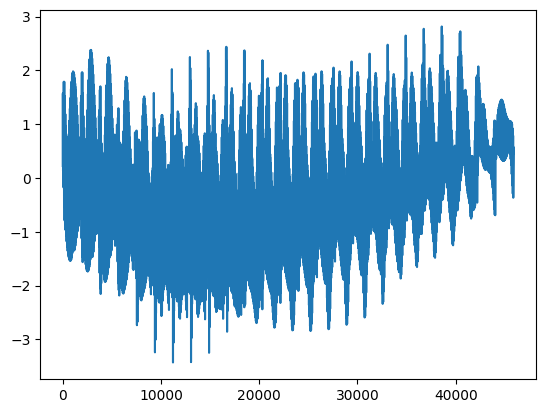

In [33]:
plt.plot(prior_k)

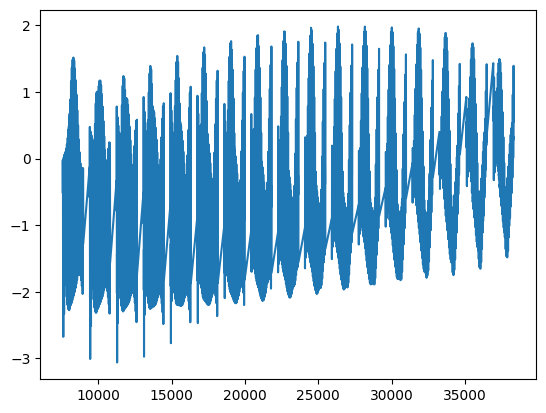

In [42]:
# read prior information
iter = 20
file_name = "inverse/O-kestimate_0622.dat"
df_mean, df_var = parse_estimation(file_name, dim =3)

prior_k = df_mean[f'iter_{iter}'].values
df_prior = df_mean[['x', 'y', 'z']].copy()
df_prior['lnK'] = prior_k  # np.log(prior_k*0.001)

df_prior_core = df_prior[
    (df_prior['x'] >= 132) & (df_prior['x'] <= 445) &
    (df_prior['y'] >= 96) & (df_prior['y'] <= 286) &
    (df_prior['z'] >= 95) & (df_prior['z'] <= 195)
]

plt.plot(df_prior_core['lnK'])

# plot_3d_isosurfaces(df_prior_core, f'iter_{iter}', 8, [-1, 1], 'Mean')

# layer contour plot
# z = df_prior_core["z"].unique()
# save_path = os.path.join(proj_dir, 'figure', 'before_clogging')
# for j in range(len(z)):
#     plot_contour_at_z(df_prior_core, z[j], f"iter_{iter}", [-12, -6], 15)